# Adaptive decomposition: three-condition comparison

This notebook compares three decomposition conditions on the same simulated dataset
(index flexion at 15% MVC, wrist angle 0 → −40° staircase pattern).
The first 30 s is the calibration segment; adaptation runs over all 190 s.

| Condition | Optimiser | Objective |
|---|---|---|
| **No adaptation** | — | — |
| **Legacy (single-obj)** | Optuna TPE | wh_loss + sv_loss + centroid_loss (scalar) |
| **Multi-objective** | NSGA-II | wh_loss, sv_loss, centroid_loss (Pareto front) |

**Loss definitions**
- **wh_loss**: KL divergence between online and calibration whitened covariance (median over batches)
- **sv_loss**: squared contrast error (log-cosh kurtosis vs. calibration) per source
- **centroid_loss**: squared centroid deviation from calibration (spike + base) per source

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from matplotlib.patches import Rectangle

from adapt_decomp.loaders import load_example
from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.optimize import optimize_adapt_decomp, run_with_optimization
from adapt_decomp.utils import (
    rate_of_agreement_paired, rate_of_agreement,
    get_coefficient_of_variation, get_discharge_rate,
    get_pulse_to_noise_ratio, get_silhouette_measure,
    find_reliable_units,
)

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)

In [2]:
import json

# ── Run control ──────────────────────────────────────────────────────────────
RUN_OPTIMISATION = True    # True = run Optuna; False = load saved results
RESULTS_DIR = Path('..', 'data', 'example', 'opt_results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def _to_json_safe(v):
    if isinstance(v, torch.Tensor):
        return v.item()
    if hasattr(v, 'item'):
        return v.item()
    return v

## 1. Load data

In [3]:
path_emg    = Path('..', 'data', 'example', 'data_sim.hdf5')
path_decomp = Path('..', 'data', 'example', 'decomp_sim.mat')

data = load_example(path_emg, path_decomp, False)
print(data.keys())

n_units = data['sep_vectors'].shape[0]
print(f'Units: {n_units},  samples: {data["emg"].shape[0]},  fs: {data["fs"]} Hz')

dict_keys(['emg', 'timestamps', 'fs', 'force_profile', 'angle_profile', 'ch_map', 'whitening', 'sep_vectors', 'base_centr', 'spikes_centr', 'ext_fact', 'emg_calib', 'ipts_calib', 'spikes_calib', 'spikes_gt', 'preprocess'])
Units: 18,  samples: 389120,  fs: 2048 Hz


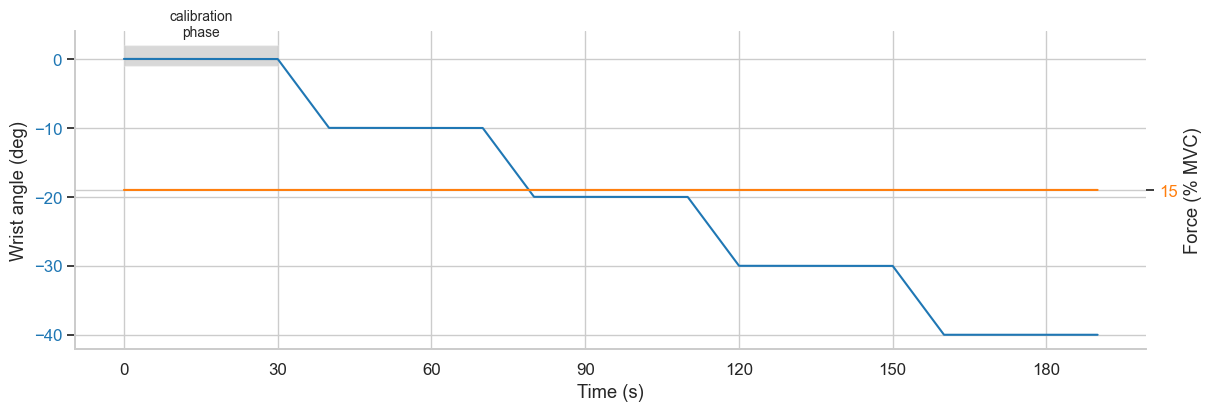

In [4]:
fig, ax = plt.subplots(figsize=(12, 4), layout='constrained')
ax.add_patch(Rectangle((0, -1), 30, 3, facecolor='grey', alpha=0.3))
ax.text(15, 5, 'calibration\nphase', dict(ha='center', va='center', fontsize=10))
ax.plot(data['timestamps'], data['angle_profile'], color='tab:blue')
ax.set(ylabel='Wrist angle (deg)', xlabel='Time (s)')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax1 = ax.twinx()
ax1.plot(data['timestamps'], data['force_profile'], color='tab:orange')
ax1.set(ylabel='Force (% MVC)', yticks=[15])
ax1.tick_params(axis='y', labelcolor='tab:orange')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
    ax1.spines[spine].set_visible(False)
ax1.set(xticks=range(0, 191, 30))
plt.show()

## 2. No adaptation

All adaptation flags disabled; the calibration whitening matrix and separation vectors are applied unchanged to the full recording.

In [5]:
cfg_no = Config()
cfg_no.ext_fact          = data['ext_fact']
cfg_no.adapt_wh          = False
cfg_no.adapt_sv          = False
cfg_no.adapt_sd          = False
cfg_no.compute_loss      = True
cfg_no.log_centroid_loss = True
cfg_no.device            = 'cpu'
cfg_no.wh_mode           = 'kl_to_cal'
cfg_no.contrast_scope    = 'spike_based'
cfg_no.wh_b_coupling     = True

dec_no = AdaptDecomp(
    emg          = data['emg'].clone(),
    whitening    = data['whitening'].clone(),
    sep_vectors  = data['sep_vectors'].clone(),
    base_centr   = data['base_centr'].clone(),
    spikes_centr = data['spikes_centr'].clone(),
    emg_calib    = data['emg_calib'].clone(),
    ipts_calib   = data['ipts_calib'].clone(),
    spikes_calib = data['spikes_calib'].clone(),
    preprocess   = data['preprocess'],
    config       = cfg_no,
)
out_no = dec_no.run()
print('No-adaptation run complete.')

No-adaptation run complete.


## 3. Legacy single-objective optimisation

`optimize_adapt_decomp` wraps Optuna TPE over `max_rel_delta_v` and `max_rel_delta_b`.  
The objective is **wh_loss + sv_loss + centroid_loss** combined as a single scalar
(`optim_loss='legacy'`), z-scored so the step-size hyperparameters are scale-free.

In [6]:
base_config = {
    'ext_fact':          data['ext_fact'],
    'adapt_wh':          True,
    'adapt_sv':          True,
    'adapt_sd':          True,
    'wh_mode':           'kl_to_cal',
    'contrast_scope':    'spike_based',
    'compute_loss':      True,
    'device':            'cpu',
    'eta_v':             1,
    'eta_b':             1,
    'trace_check':       True,
    'log_wh_trace':      True,
    'log_centroid_loss': True,
    'optim_loss':        'legacy',
    'wh_b_coupling':     True,
}

param_space = {
    'max_rel_delta_v': ('log_float', 1e-4, 1.0),
    'max_rel_delta_b': ('log_float', 1e-4, 1.0),
}

_cfg_leg_path   = RESULTS_DIR / 'best_config_leg.json'
_study_leg_path = RESULTS_DIR / 'study_leg_trials.csv'

if RUN_OPTIMISATION:
    best_config_leg, study_leg = optimize_adapt_decomp(
        emg          = data['emg'],
        whitening    = data['whitening'],
        sep_vectors  = data['sep_vectors'],
        base_centr   = data['base_centr'],
        spikes_centr = data['spikes_centr'],
        emg_calib    = data['emg_calib'],
        ipts_calib   = data['ipts_calib'],
        spikes_calib = data['spikes_calib'],
        param_space  = param_space,
        base_config  = base_config,
        n_trials     = 30,
        preprocess   = data['preprocess'],
    )
    with open(_cfg_leg_path, 'w') as f:
        json.dump({k: _to_json_safe(v) for k, v in best_config_leg.items()}, f, indent=2)
    pd.DataFrame([{'trial': t.number, 'value': t.value, **t.params}
                  for t in study_leg.trials if t.value is not None]).to_csv(_study_leg_path, index=False)
    print(f'Saved → {_cfg_leg_path}')
else:
    with open(_cfg_leg_path) as f:
        best_config_leg = json.load(f)
    study_leg = None
    print(f'Loaded from {_cfg_leg_path}')

print('Best hyperparameters (legacy):')
for k, v in best_config_leg.items():
    if k in param_space:
        print(f'  {k}: {v:.4e}')

Saved → ../data/example/opt_results/best_config_leg.json
Best hyperparameters (legacy):
  max_rel_delta_v: 6.7909e-03
  max_rel_delta_b: 3.6469e-02


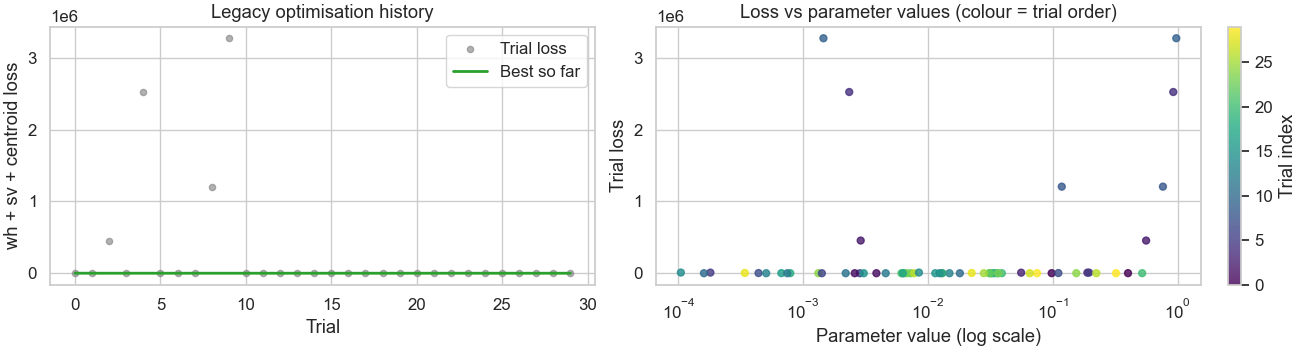

In [7]:
%matplotlib widget
if study_leg is None:
    print('Optimisation history not available (results loaded from file).')
else:
    values = [t.value for t in study_leg.trials]
    best_so_far = np.minimum.accumulate(values)

    fig, axs = plt.subplots(1, 2, figsize=(13, 3.5), layout='constrained')

    axs[0].scatter(range(len(values)), values, s=20, alpha=0.6, color='tab:grey', label='Trial loss')
    axs[0].plot(range(len(values)), best_so_far, color='tab:green', linewidth=2, label='Best so far')
    axs[0].set(xlabel='Trial', ylabel='wh + sv + centroid loss', title='Legacy optimisation history')
    axs[0].legend()

    for i, name in enumerate(param_space):
        vals = [t.params[name] for t in study_leg.trials if name in t.params]
        cols = [t.value      for t in study_leg.trials if name in t.params]
        sc = axs[1].scatter(vals, cols, c=range(len(vals)), cmap='viridis', s=25, alpha=0.8)

    axs[1].set(xlabel='Parameter value (log scale)', xscale='log',
               ylabel='Trial loss', title='Loss vs parameter values (colour = trial order)')
    plt.colorbar(sc, ax=axs[1], label='Trial index')
    plt.show()

Apply the best legacy configuration and run the full decomposition to obtain outputs (losses, timing, IPTs, spikes).

In [8]:
_out_leg_path = RESULTS_DIR / 'out_leg.pt'

if RUN_OPTIMISATION:
    cfg_leg = Config()
    for k, v in best_config_leg.items():
        setattr(cfg_leg, k, v)

    dec_leg = AdaptDecomp(
        emg          = data['emg'].clone(),
        whitening    = data['whitening'].clone(),
        sep_vectors  = data['sep_vectors'].clone(),
        base_centr   = data['base_centr'].clone(),
        spikes_centr = data['spikes_centr'].clone(),
        emg_calib    = data['emg_calib'].clone(),
        ipts_calib   = data['ipts_calib'].clone(),
        spikes_calib = data['spikes_calib'].clone(),
        preprocess   = data['preprocess'],
        config       = cfg_leg,
    )
    out_leg = dec_leg.run()
    torch.save(out_leg, _out_leg_path)
    print(f'Saved → {_out_leg_path}')
else:
    out_leg = torch.load(_out_leg_path, weights_only=False)
    print(f'Loaded from {_out_leg_path}')

print('Legacy adaptation run complete.')

Saved → ../data/example/opt_results/out_leg.pt
Legacy adaptation run complete.


## 4. Multi-objective optimisation (NSGA-II)

NSGA-II treats **wh_loss**, **sv_loss**, and **centroid_loss** as three independent objectives
and returns a Pareto front instead of a single scalar.
The operating point is selected from the front by **minimum sum** of the three objectives;
`study_mo.best_trials` exposes the full front.

In [9]:
_cfg_mo_path = RESULTS_DIR / 'best_config_mo.json'
_out_mo_path = RESULTS_DIR / 'out_mo.pt'

base_config_mo = {
    **base_config,
    'optim_loss': 'source',   # returns (wh_loss, sv_loss, centroid_loss) 3-tuple for Pareto
}

if RUN_OPTIMISATION:
    out_mo, best_config_mo, study_mo = run_with_optimization(
        emg          = data['emg'],
        whitening    = data['whitening'],
        sep_vectors  = data['sep_vectors'],
        base_centr   = data['base_centr'],
        spikes_centr = data['spikes_centr'],
        emg_calib    = data['emg_calib'],
        ipts_calib   = data['ipts_calib'],
        spikes_calib = data['spikes_calib'],
        param_space  = param_space,
        base_config  = base_config_mo,
        n_trials     = 50,
        preprocess   = data['preprocess'],
        optim_mode   = 'multiobjective',
    )
    with open(_cfg_mo_path, 'w') as f:
        json.dump({k: _to_json_safe(v) for k, v in best_config_mo.items()}, f, indent=2)
    torch.save(out_mo, _out_mo_path)
    print(f'Saved → {_cfg_mo_path}, {_out_mo_path}')
    print(f'Pareto front: {len(study_mo.best_trials)} trials')
else:
    with open(_cfg_mo_path) as f:
        best_config_mo = json.load(f)
    out_mo   = torch.load(_out_mo_path, weights_only=False)
    study_mo = None
    print(f'Loaded from {_cfg_mo_path}, {_out_mo_path}')

print('Selected config (multi-objective):')
for k, v in best_config_mo.items():
    if k in param_space:
        print(f'  {k}: {v:.4e}')

Saved → ../data/example/opt_results/best_config_mo.json, ../data/example/opt_results/out_mo.pt
Pareto front: 6 trials
Selected config (multi-objective):
  max_rel_delta_v: 3.7943e-03
  max_rel_delta_b: 6.4564e-02


/opt/miniconda3/envs/decomposition/lib/python3.11/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  self.figure.savefig(buf, format='png', dpi='figure')
/opt/miniconda3/envs/decomposition/lib/python3.11/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  self.figure.savefig(buf, format='png', dpi='figure')


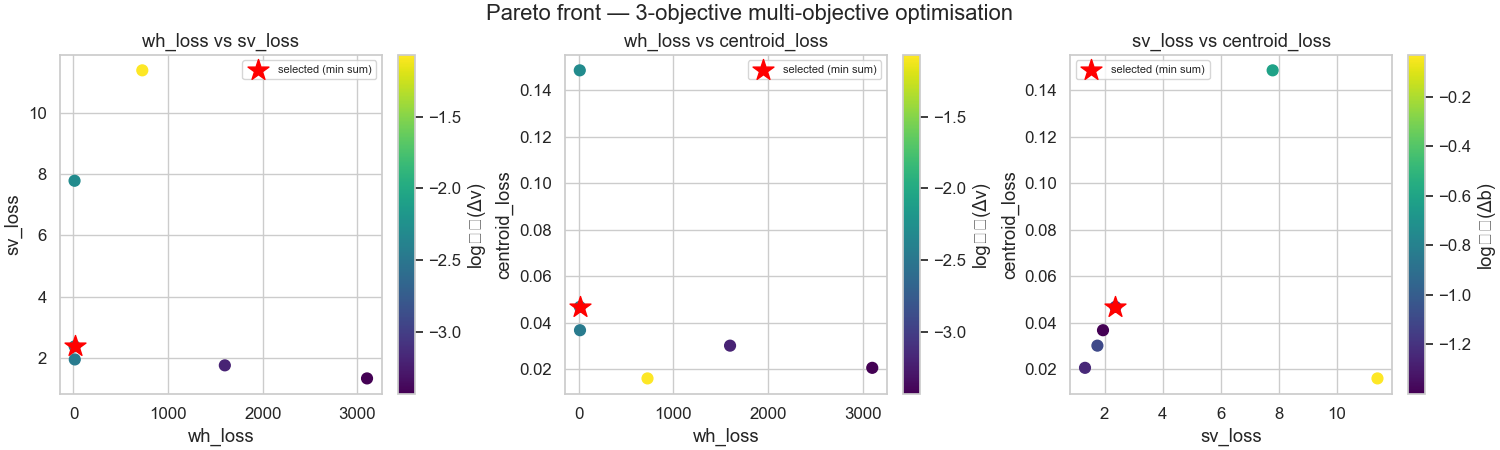

Pareto front: 6 non-dominated trials
Selected: wh=12.8163, sv=2.3718, centroid=0.0468


In [10]:
if study_mo is None:
    print('Pareto front not available (results loaded from file).')
else:
    pareto_trials = study_mo.best_trials
    wh_vals   = [t.values[0] for t in pareto_trials]
    sv_vals   = [t.values[1] for t in pareto_trials]
    cent_vals = [t.values[2] for t in pareto_trials]
    dv_vals   = [t.params.get('max_rel_delta_v', float('nan')) for t in pareto_trials]
    db_vals   = [t.params.get('max_rel_delta_b', float('nan')) for t in pareto_trials]
    sel_idx   = int(np.argmin([w + s + c for w, s, c in zip(wh_vals, sv_vals, cent_vals)]))

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), layout='constrained')

    for ax, (xa, ya, c_vals, clbl, lbl) in zip(axs, [
        (wh_vals,   sv_vals,   dv_vals, 'log₁₀(Δv)', 'wh_loss vs sv_loss'),
        (wh_vals,   cent_vals, dv_vals, 'log₁₀(Δv)', 'wh_loss vs centroid_loss'),
        (sv_vals,   cent_vals, db_vals, 'log₁₀(Δb)', 'sv_loss vs centroid_loss'),
    ]):
        sc = ax.scatter(xa, ya, c=np.log10(c_vals), cmap='viridis', s=60, zorder=3)
        ax.scatter(xa[sel_idx], ya[sel_idx], marker='*', s=250, color='red',
                   zorder=4, label='selected (min sum)')
        plt.colorbar(sc, ax=ax, label=clbl)
        ax.set(xlabel=lbl.split(' vs ')[0], ylabel=lbl.split(' vs ')[1], title=lbl)
        ax.legend(fontsize=8)

    plt.suptitle('Pareto front — 3-objective multi-objective optimisation')
    plt.show()

    print(f'Pareto front: {len(pareto_trials)} non-dominated trials')
    print(f'Selected: wh={wh_vals[sel_idx]:.4f}, sv={sv_vals[sel_idx]:.4f}, centroid={cent_vals[sel_idx]:.4f}')

## 5. Execution time per batch

In [11]:
cond_labels  = ['No adaptation', 'Legacy (single-obj)', 'Multi-objective']
cond_colors  = {
    'No adaptation':       'tab:orange',
    'Legacy (single-obj)': 'tab:blue',
    'Multi-objective':     'tab:green',
}
cond_outputs = {
    'No adaptation':       out_no,
    'Legacy (single-obj)': out_leg,
    'Multi-objective':     out_mo,
}

for label in cond_labels:
    out = cond_outputs[label]
    print(label)
    print('-' * len(label))
    for key in ['wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
        print(f'  {key:>15}: {out[key].mean():.3f} ± {out[key].std():.3f} ms')
    print()

No adaptation
-------------
       wh_time_ms: 12.437 ± 2.438 ms
       sv_time_ms: 0.078 ± 0.027 ms
       sd_time_ms: 0.720 ± 0.382 ms
    total_time_ms: 13.234 ± 2.480 ms

Legacy (single-obj)
-------------------
       wh_time_ms: 15.458 ± 2.748 ms
       sv_time_ms: 0.597 ± 0.274 ms
       sd_time_ms: 0.674 ± 0.374 ms
    total_time_ms: 16.729 ± 2.783 ms

Multi-objective
---------------
       wh_time_ms: 17.812 ± 3.668 ms
       sv_time_ms: 0.572 ± 0.275 ms
       sd_time_ms: 0.678 ± 0.408 ms
    total_time_ms: 19.061 ± 3.690 ms



## 6. Loss trajectories

- **wh_loss**: scalar KL error² (median over batches)
- **sv_loss**: squared contrast error per source (log-cosh kurtosis deviation from calibration)
- **centroid_loss**: squared centroid deviation per source (√ = RMS shift in detection-domain units)

A value near zero means the online statistics match calibration.

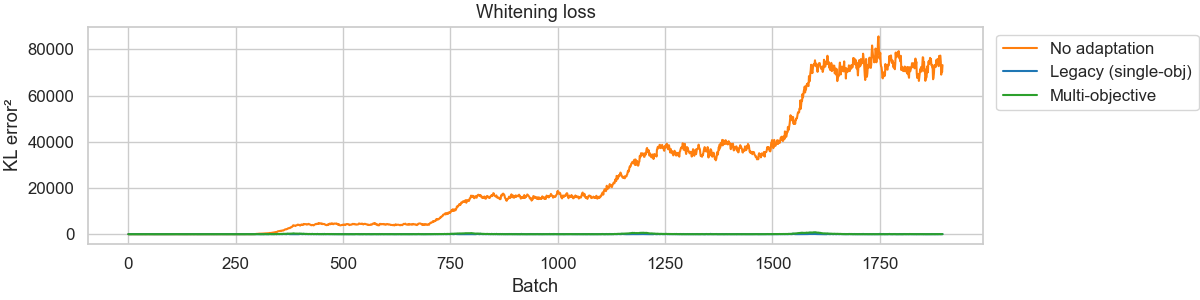

In [12]:
fig, ax = plt.subplots(figsize=(12, 3), layout='constrained')
for label in cond_labels:
    ax.plot(cond_outputs[label]['wh_loss'][10:-1], label=label, color=cond_colors[label])
ax.set(xlabel='Batch', ylabel='KL error²', title='Whitening loss')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()

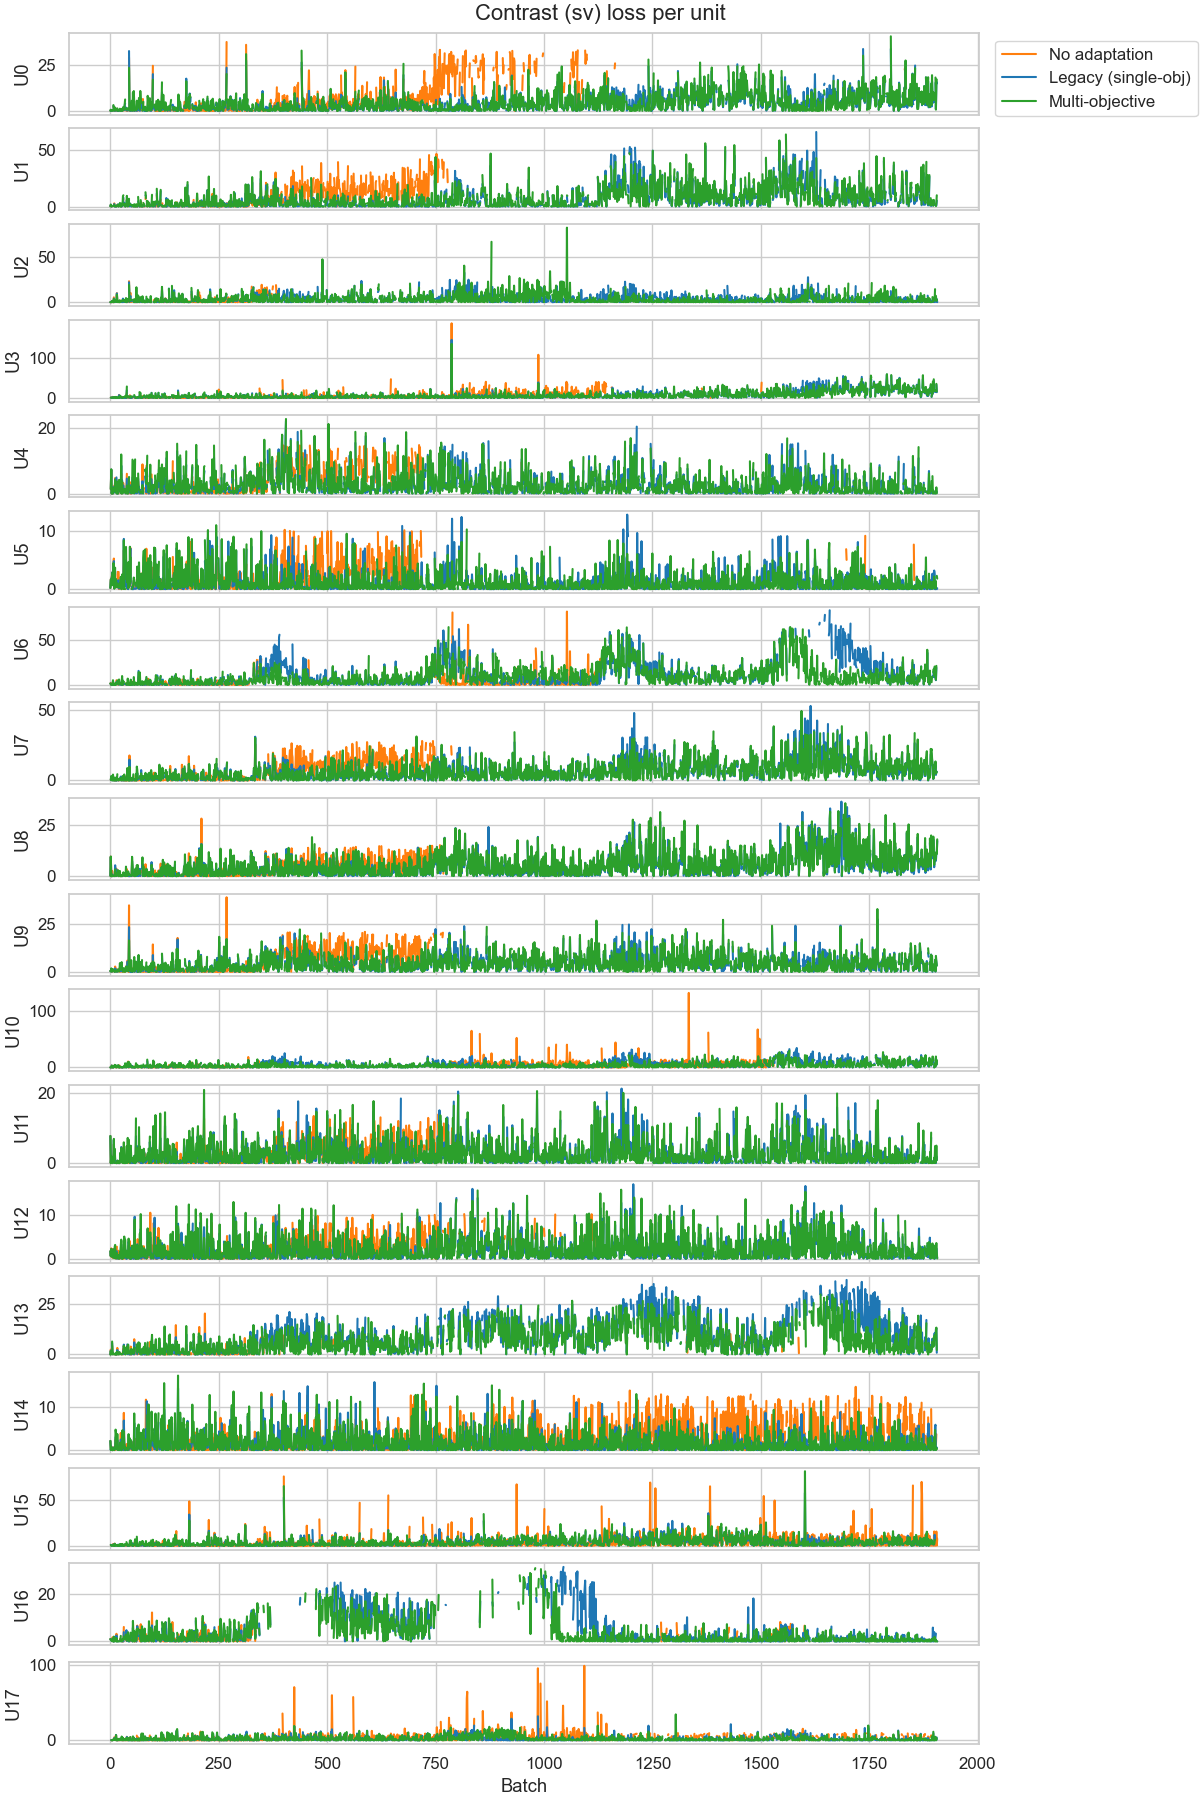

In [13]:
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        axs[u].plot(cond_outputs[label]['sv_loss'][:, u], label=label, color=cond_colors[label])
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('Contrast (sv) loss per unit')
plt.show()

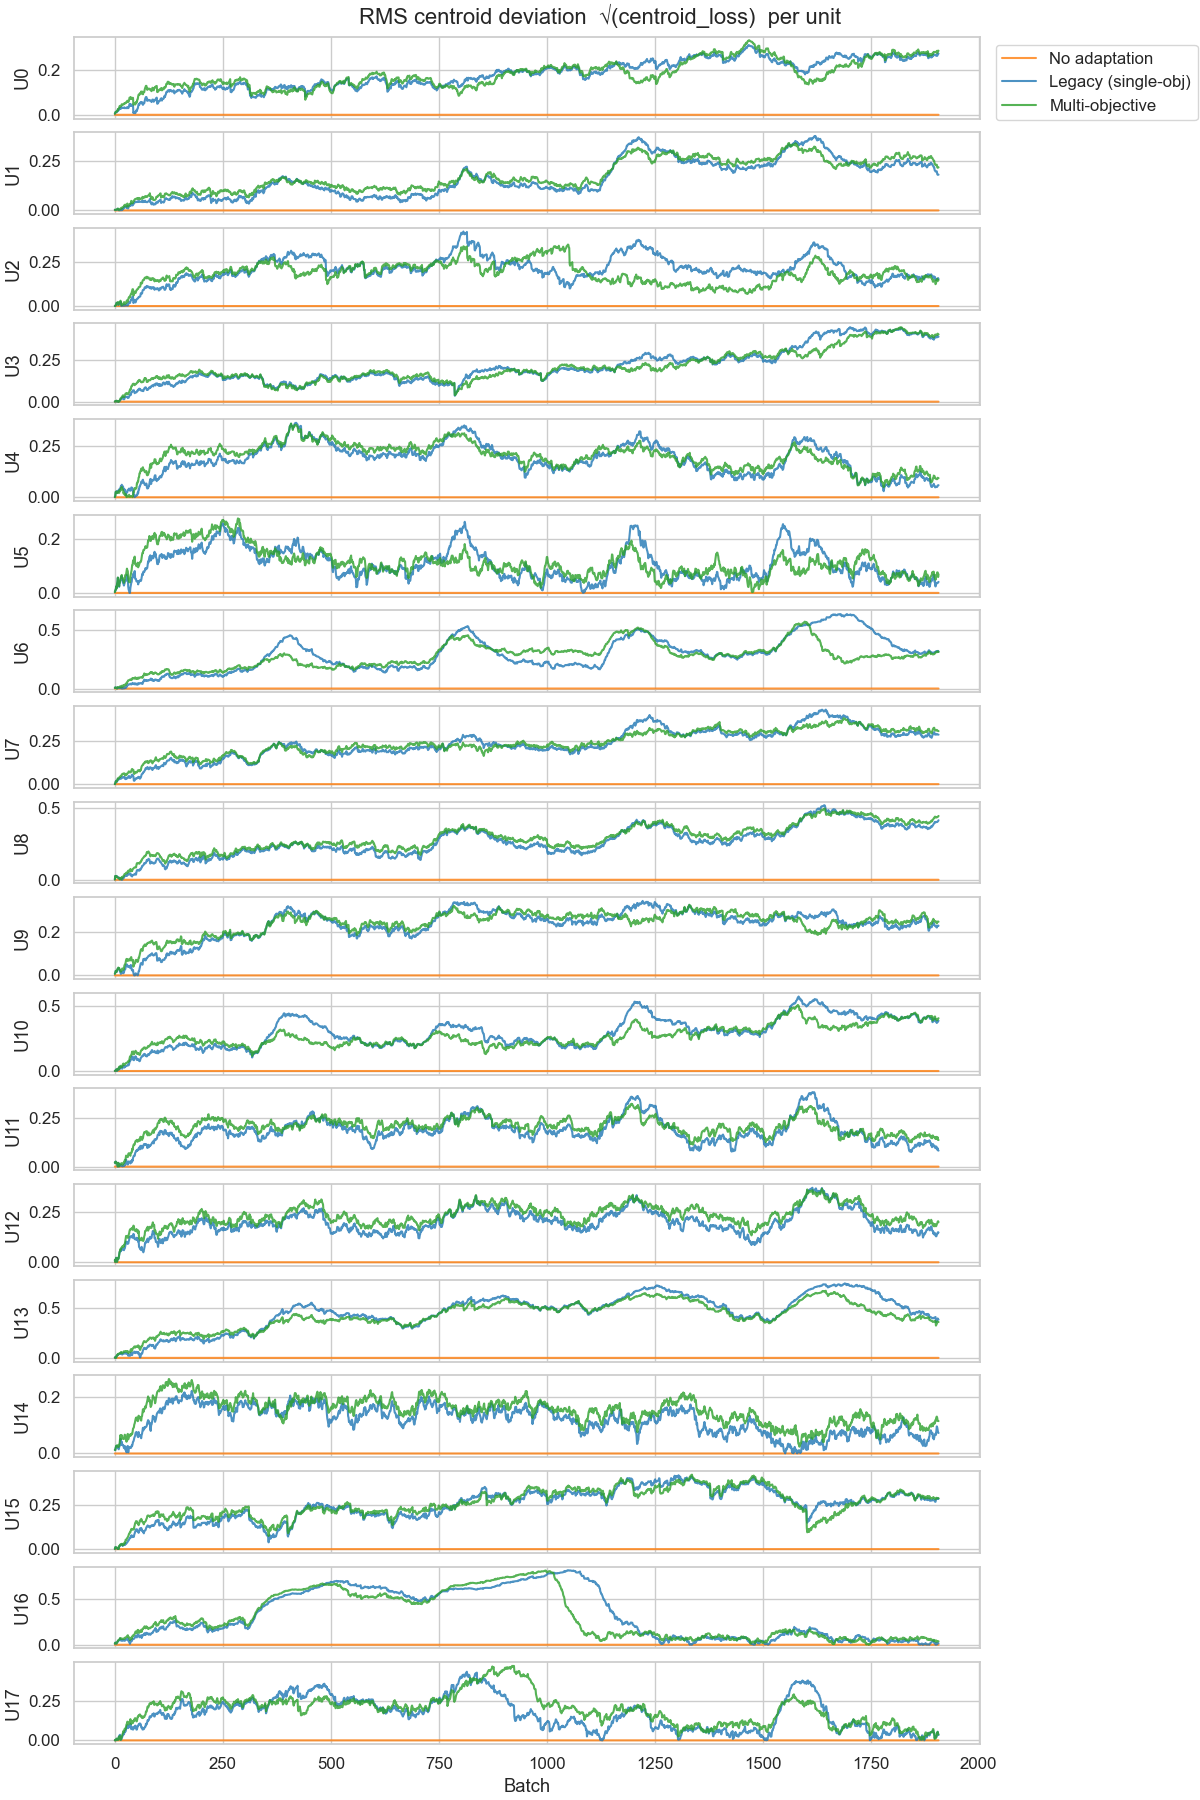

In [14]:
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        out = cond_outputs[label]
        if 'centroid_loss' in out:
            axs[u].plot(
                np.sqrt(out['centroid_loss'][:, u].numpy()),
                label=label, color=cond_colors[label], alpha=0.8,
            )
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('RMS centroid deviation  √(centroid_loss)  per unit')
plt.show()

## 7. IPTs and spike trains

Full recording (0–190 s). Squared IPTs with detected spike times overlaid.

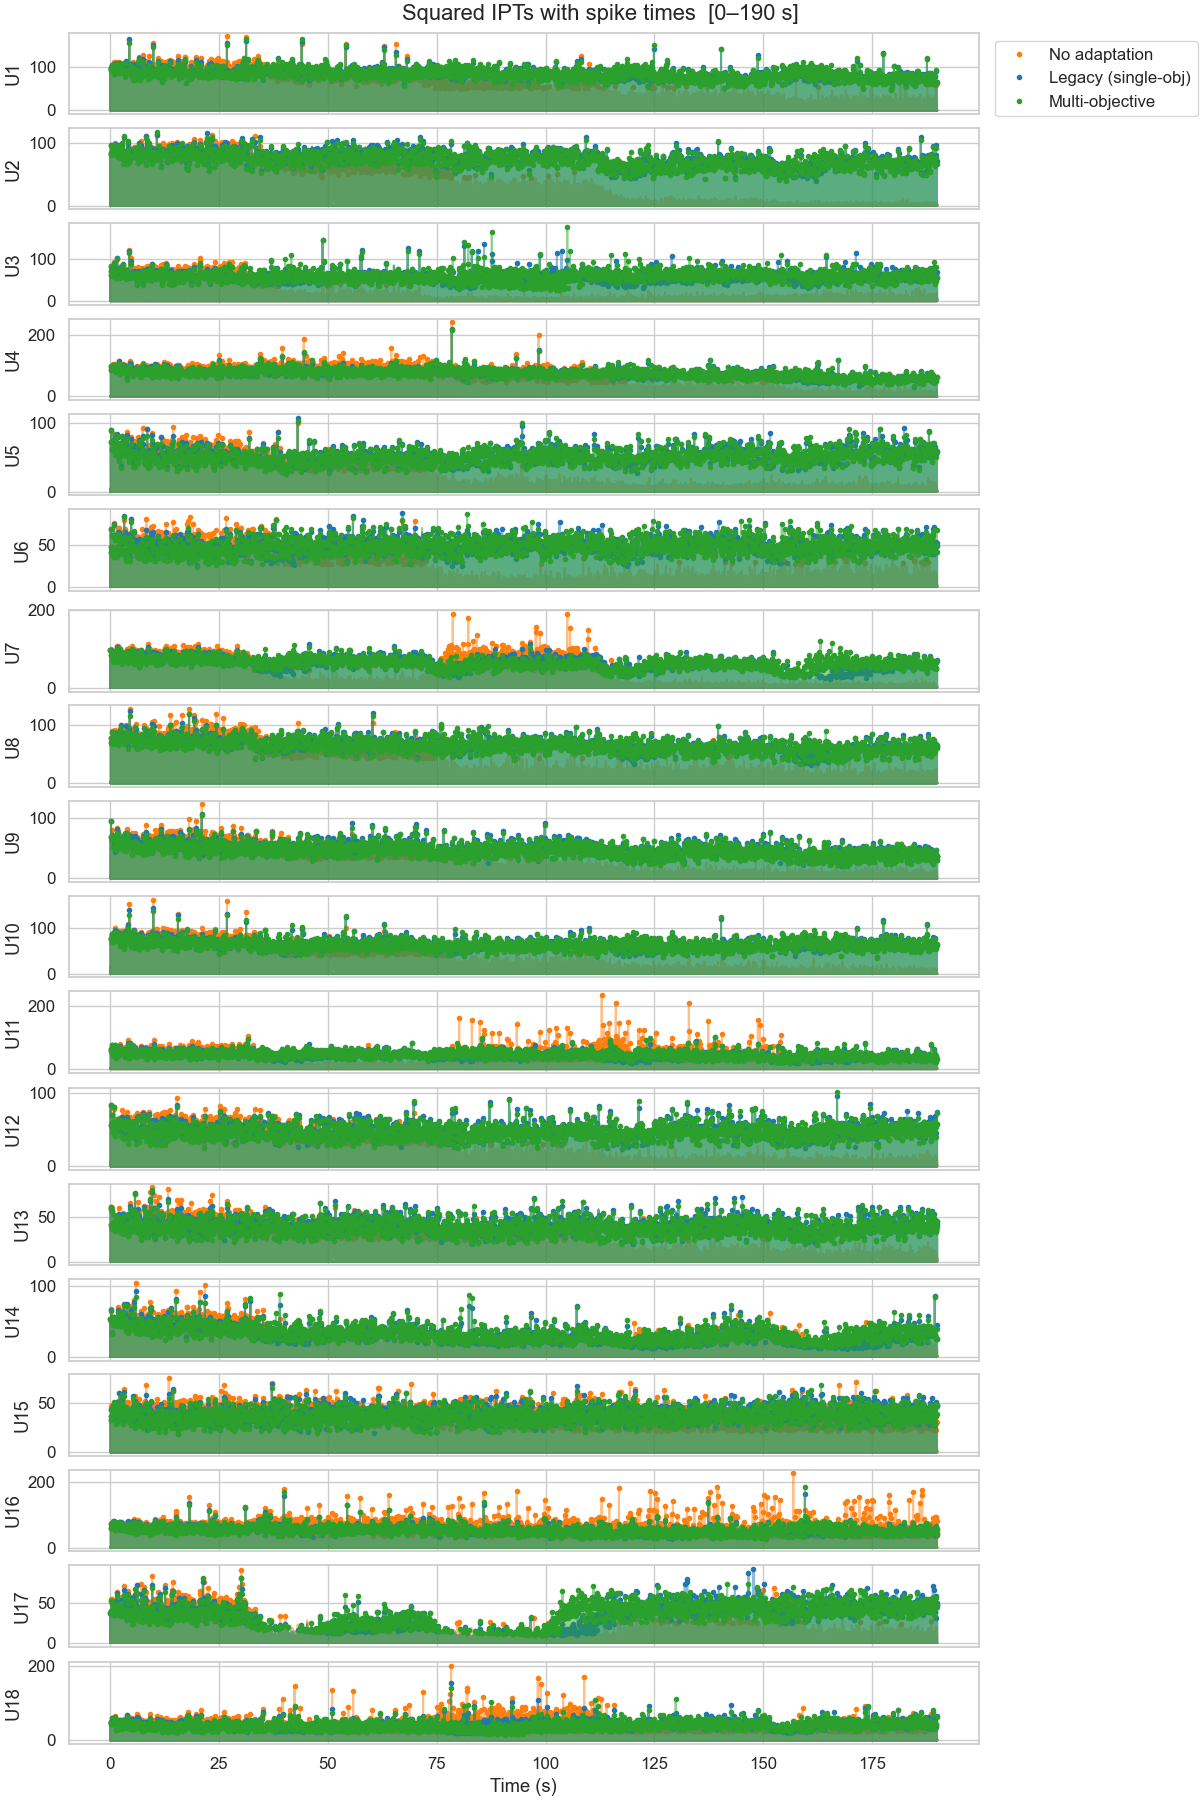

In [15]:
t0, t1 = 0, 190
idxs = np.arange(int(t0 * data['fs']), int(t1 * data['fs']))

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)

for u in range(n_units):
    for label in cond_labels:
        out = cond_outputs[label]
        ipts_sq = out['ipts'][idxs, u].numpy() ** 2
        axs[u].plot(data['timestamps'][idxs], ipts_sq, color=cond_colors[label], alpha=0.5)
        spike_mask = out['spikes'][idxs, u].to(bool)
        axs[u].plot(
            data['timestamps'][idxs][spike_mask],
            ipts_sq[spike_mask],
            linestyle='None', marker='.', color=cond_colors[label],
            label=label if u == 0 else None,
        )
    axs[u].set(ylabel=f'U{u + 1}')

axs[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Time (s)')
plt.suptitle(f'Squared IPTs with spike times  [{t0}–{t1} s]')
plt.show()

## 8. Decomposition quality metrics

Silhouette measure (SIL), pulse-to-noise ratio (PNR), discharge rate (DR), and coefficient of variation (CoV) compared across all three conditions.  
A unit is **good** if SIL ≥ 0.9, DR ∈ [5, 35] pps, CoV ≤ 35%, PNR ≥ 30 dB.

In [16]:
timestamps_np = data['timestamps'].numpy()
ext_fact      = data['ext_fact']

cond_labels  = ['No adaptation', 'Legacy (single-obj)', 'Multi-objective']
cond_colors  = {
    'No adaptation':       'tab:orange',
    'Legacy (single-obj)': 'tab:blue',
    'Multi-objective':     'tab:green',
}
cond_outputs = {
    'No adaptation':       out_no,
    'Legacy (single-obj)': out_leg,
    'Multi-objective':     out_mo,
}

rows = []
for label in cond_labels:
    out       = cond_outputs[label]
    spikes_np = out['spikes'].numpy().astype(float)
    ipts_np   = out['ipts'].numpy()

    sil  = get_silhouette_measure(spikes_np, ipts_np, ext_fact)
    pnr  = get_pulse_to_noise_ratio(spikes_np, ipts_np, ext_fact)
    dr   = get_discharge_rate(spikes_np, timestamps_np, discard_isi=None)
    cov  = get_coefficient_of_variation(spikes_np, timestamps_np, discard_isi=None)
    good = find_reliable_units(dr, cov, sil, pnr, dr_low_thr=5, dr_upp_thr=35,
                               cov_thr=0.35, sil_thr=0.9, pnr_thr=30)
    for u in range(spikes_np.shape[1]):
        rows.append({'unit': u, 'condition': label, 'good': bool(good[u]),
                     'SIL': sil[u], 'PNR (dB)': pnr[u], 'DR (pps)': dr[u], 'CoV (%)': cov[u]})

df_all  = pd.DataFrame(rows)
n_total = df_all['unit'].nunique()

print(df_all.groupby('condition')[['SIL', 'PNR (dB)', 'DR (pps)', 'CoV (%)']]
        .agg(['median', 'mean']).round(2))
print()
for cond, grp in df_all.groupby('condition'):
    print(f'{cond}: {grp["good"].sum()} / {n_total} good units')

                       SIL       PNR (dB)        DR (pps)       CoV (%)      
                    median  mean   median   mean   median  mean  median  mean
condition                                                                    
Legacy (single-obj)   0.96  0.95    35.53  35.68     9.09  9.15    0.22  0.31
Multi-objective       0.96  0.95    34.89  35.11     9.11  9.30    0.23  0.29
No adaptation         0.94  0.93    31.78  32.16     5.41  5.91    3.17  3.21

Legacy (single-obj): 15 / 18 good units
Multi-objective: 15 / 18 good units
No adaptation: 0 / 18 good units


/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_46111/3039117822.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_46111/3039117822.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_46111/3039117822.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=

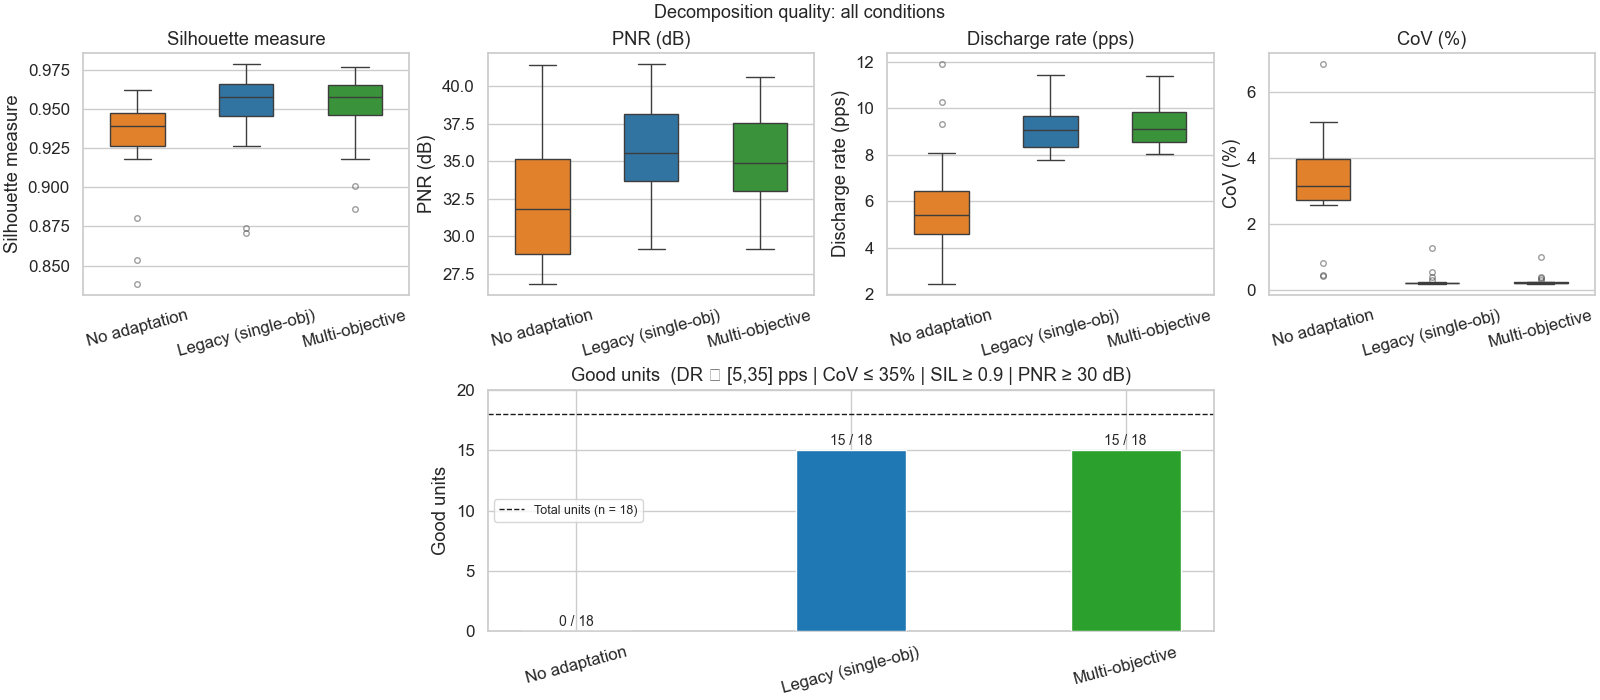

In [17]:
order   = cond_labels
palette = cond_colors

df_all['condition'] = pd.Categorical(df_all['condition'], categories=order, ordered=True)

fig = plt.figure(figsize=(16, 7), layout='constrained')
gs  = fig.add_gridspec(2, 4)

ax_sil = fig.add_subplot(gs[0, 0])
ax_pnr = fig.add_subplot(gs[0, 1])
ax_dr  = fig.add_subplot(gs[0, 2])
ax_cov = fig.add_subplot(gs[0, 3])
ax_bar = fig.add_subplot(gs[1, 1:3])

for ax, col, ylabel in [
    (ax_sil, 'SIL',      'Silhouette measure'),
    (ax_pnr, 'PNR (dB)', 'PNR (dB)'),
    (ax_dr,  'DR (pps)', 'Discharge rate (pps)'),
    (ax_cov, 'CoV (%)',  'CoV (%)'),
]:
    sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
                width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
    ax.set(xlabel='', ylabel=ylabel, title=ylabel)
    ax.tick_params(axis='x', rotation=15)

good_counts = df_all.groupby('condition', observed=True)['good'].sum().reindex(order)
bars = ax_bar.bar(order, good_counts.values,
                  color=[palette[c] for c in order], width=0.4, zorder=3)
ax_bar.axhline(n_total, color='k', linestyle='--', linewidth=1,
               label=f'Total units (n = {n_total})')
ax_bar.set(ylabel='Good units', ylim=(0, n_total + 2),
           title='Good units  (DR ∈ [5,35] pps | CoV ≤ 35% | SIL ≥ 0.9 | PNR ≥ 30 dB)')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=15)
for bar, count in zip(bars, good_counts.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, count + 0.2,
                f'{int(count)} / {n_total}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Decomposition quality: all conditions', fontsize=13)
plt.show()

## 9. Rate of agreement with ground truth

Unit matching is performed on the calibration segment (first 30 s) using the no-adaptation pairing as the common reference. The bottom subplot shows whether each unit is classified as **good** (●) or **bad** (✗) under each condition, enabling direct correlation between separation quality and agreement with ground truth.

In [18]:
cal_idx = np.arange(0, int(30 * data['fs']))

roa_no_cal,  pair_no,  _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_no['spikes'].numpy()[cal_idx],
    fs=data['fs'],
)
roa_leg_cal, pair_leg, _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_leg['spikes'].numpy()[cal_idx],
    fs=data['fs'],
)
roa_mo_cal,  pair_mo,  _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_mo['spikes'].numpy()[cal_idx],
    fs=data['fs'],
)

print(f'RoA calibration | No adaptation:       {roa_no_cal.mean()*100:.2f} ± {roa_no_cal.std()*100:.2f}%')
print(f'RoA calibration | Legacy (single-obj): {roa_leg_cal.mean()*100:.2f} ± {roa_leg_cal.std()*100:.2f}%')
print(f'RoA calibration | Multi-objective:     {roa_mo_cal.mean()*100:.2f} ± {roa_mo_cal.std()*100:.2f}%')

# No-adapt pairing is the common reference across all conditions
pair_arr   = np.array(pair_no)
sim_spikes = data['spikes_gt'].numpy()[:, pair_arr[:, 0]]

RoA calibration | No adaptation:       99.40 ± 0.49%
RoA calibration | Legacy (single-obj): 99.29 ± 0.53%
RoA calibration | Multi-objective:     99.25 ± 0.59%


RoA full | No adaptation:       37.88 ± 18.23%  (med: 37.29%)
RoA full | Legacy (single-obj): 89.65 ± 24.03%  (med: 99.11%)
RoA full | Multi-objective:     86.45 ± 26.85%  (med: 98.91%)


/opt/miniconda3/envs/decomposition/lib/python3.11/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  self.figure.savefig(buf, format='png', dpi='figure')


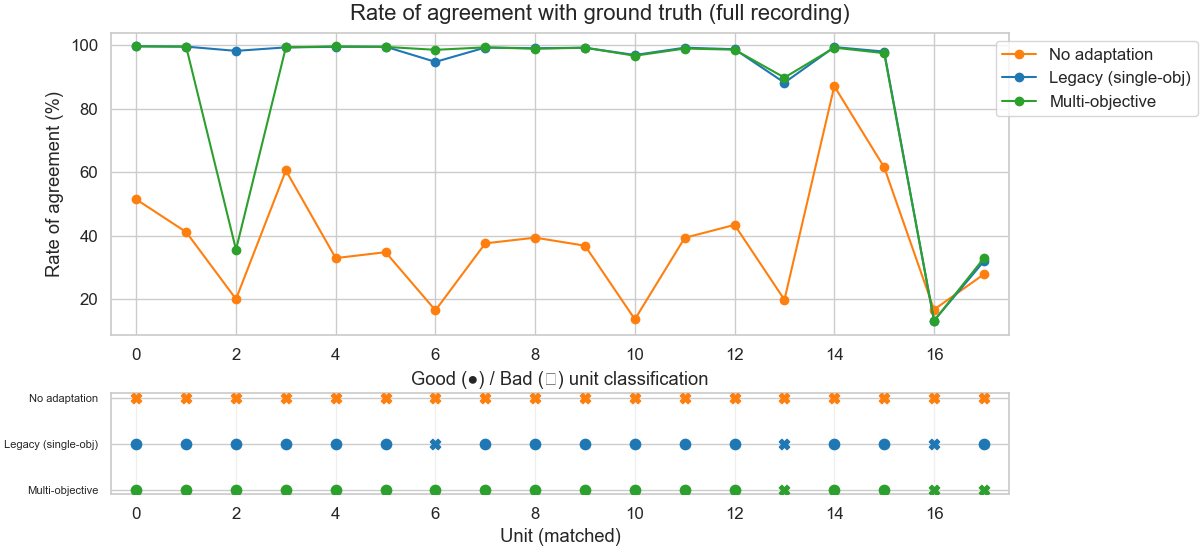

In [19]:
roa_no_full,  _, _ = rate_of_agreement_paired(sim_spikes, out_no['spikes'].numpy(),  fs=data['fs'], tol_spike_ms=2)
roa_leg_full, _, _ = rate_of_agreement_paired(sim_spikes, out_leg['spikes'].numpy(), fs=data['fs'], tol_spike_ms=2)
roa_mo_full,  _, _ = rate_of_agreement_paired(sim_spikes, out_mo['spikes'].numpy(),  fs=data['fs'], tol_spike_ms=2)

unit_ids = pair_arr[:, 1]
n_pairs  = len(unit_ids)
x        = np.arange(n_pairs)

print(f'RoA full | No adaptation:       {roa_no_full.mean()*100:.2f} ± {roa_no_full.std()*100:.2f}%  (med: {np.median(roa_no_full)*100:.2f}%)')
print(f'RoA full | Legacy (single-obj): {roa_leg_full.mean()*100:.2f} ± {roa_leg_full.std()*100:.2f}%  (med: {np.median(roa_leg_full)*100:.2f}%)')
print(f'RoA full | Multi-objective:     {roa_mo_full.mean()*100:.2f} ± {roa_mo_full.std()*100:.2f}%  (med: {np.median(roa_mo_full)*100:.2f}%)')

good_lookup = {
    label: df_all[df_all['condition'] == label].set_index('unit')['good']
    for label in cond_labels
}

fig, (ax_roa, ax_good) = plt.subplots(
    2, 1, figsize=(12, 5.5), layout='constrained',
    gridspec_kw={'height_ratios': [3, 1]},
)

ax_roa.plot(x, roa_no_full  * 100, marker='o', label='No adaptation',       color=cond_colors['No adaptation'])
ax_roa.plot(x, roa_leg_full * 100, marker='o', label='Legacy (single-obj)', color=cond_colors['Legacy (single-obj)'])
ax_roa.plot(x, roa_mo_full  * 100, marker='o', label='Multi-objective',     color=cond_colors['Multi-objective'])
ax_roa.set(ylabel='Rate of agreement (%)', xlim=(-0.5, n_pairs - 0.5))
ax_roa.legend(loc='upper right', bbox_to_anchor=(1.22, 1))

y_pos = {'No adaptation': 2, 'Legacy (single-obj)': 1, 'Multi-objective': 0}
for label in cond_labels:
    for i, uid in enumerate(unit_ids):
        is_good = bool(good_lookup[label].get(uid, False))
        ax_good.scatter(i, y_pos[label],
                        color=cond_colors[label],
                        marker='o' if is_good else 'X',
                        s=55, zorder=3)

ax_good.set_yticks(list(y_pos.values()))
ax_good.set_yticklabels(list(y_pos.keys()), fontsize=8)
ax_good.set(xlabel='Unit (matched)', xlim=(-0.5, n_pairs - 0.5),
            title='Good (●) / Bad (✗) unit classification')
ax_good.grid(axis='x', alpha=0.3)

plt.suptitle('Rate of agreement with ground truth (full recording)')
plt.show()